# Content
1. Loading <br>
2. Notation and Definitions<br>
3. KDE plots of the log likelihoods in bpd<br>
4. Outlier Datapoints<br>
5. Sampling<br>

# Goal
In this notebook we want to give an overview on how different models assign likelihoods to different datasets and datapoints and through sampling get insight into what the models have learned.

# 1. Loading
The used models can be seen in the first code cell (CHECKPOINTS).<br>
Relevant training and model information can be seen in "Relevant Training Information".

In [1]:
import sys
from os import path, getcwd
import pathlib

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

# data paths
DATA_DIR = path.join(ROOT, 'data/')
# checkpoints of preprocessed data
CHECKPOINTS = {'nf': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.15_14-22-33_normal/'),
               'nf_new_loss': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.24_13-35-41_new_loss_old/'), 
               'continued_new_loss': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.12_08-57-06_new_loss_continued/'),
               'nf_no_bias': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.11_08-25-27_no_bias/'), 
               'nf_indep': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.29_20-56-46_indep/'),
               'survae': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.11_14-20-54_normal/'),
               'survae_new_loss': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.10_20-27-32_new_loss/'),
               'survae_no_bias': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.11_08-26-49_no_bias/'),
               'survae_hierarchy': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-4_scales-5_pool-max_mnist_cls-0/06.11_09-35-05_hierarchy/'),
               'iwae_no_bias': path.join(DATA_DIR, 'checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.09_08-18-56_no_bias/'),
               'iwae_with_bias': path.join(DATA_DIR, 'checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.10_20-27-53_with_bias/')}

print(f'Loading preprocessed data from:\n {CHECKPOINTS}')

Loading preprocessed data from:
 {'nf': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.15_14-22-33_normal/', 'nf_new_loss': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.24_13-35-41_new_loss_old/', 'continued_new_loss': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.12_08-57-06_new_loss_continued/', 'nf_no_bias': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.11_08-25-27_no_bias/', 'nf_indep': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.29_20-56-46_indep/', 'survae': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.11_14-20-54_normal/', 'survae_new_loss': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.10_20-27-32_new_loss/', 'survae_no_bias': 'C:\\Mega\\trunk\\master-thesis\\data/c

In [2]:
%reload_ext autoreload
%autoreload 2

# Plotting Functions
from plotting import *
from misc.common_functions import load_configs
from precomputation.initialization import load_data, load_preprocessings
from precomputation.pre_sampling import SampleType

_=%matplotlib inline

### 1.1 Loading Models and Training Data

In [3]:
# config
configs, MAIN_TEST_CLS = load_configs(CHECKPOINTS, DATA_DIR)

for model in configs:
    configs[model].new_use_case = False

# Data
all_loaders = load_data(configs)

# Precomputed information
all_losses, samples, artificial_images, _ = load_preprocessings(CHECKPOINTS)

-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: normal
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: new_loss
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: new_loss_continued
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: no_bias
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: indep
debug: False
-------------------------------------------------------------
SurVAE
wandb_name_ext: normal
debug: False
-------------------------------------------------------------
SurVAE
debug: False
-------------------------------------------------------------
SurVAE
wandb_name_ext: no_bias
debug: False
-------------------------------------------------------------
SurVAE
wandb_name_ext: hierarchy
debug: False
----------

In [4]:
no_iwae_losses = dict()
for key in all_losses:
    if key.startswith('iwae'):
        continue
    no_iwae_losses[key] = all_losses[key]
    
iwae_losses = {'iwae_no_bias': all_losses['iwae_no_bias'], 'iwae_with_bias': all_losses['iwae_with_bias']}

--- 

# 2. Notation and Definitions


$\newcommand{\finv}{f^{-1}}$
$\newcommand{\px}{p_X(x)}$
$\newcommand{\pxbpd}{\log p_X(x) \text{ in bpd}}$
$\newcommand{\pxibpd}{\log p_X(x_i) \text{ in bpd}}$
$\newcommand{\pz}{p_Z(z)}$
$\newcommand{\fNF}{f_{\text{NF}}}$
$\newcommand{\fSVAE}{f_{\text{SVAE}}}$
$\newcommand{\finvNF}{\finv_{\text{NF}}}$
$\newcommand{\finvSVAE}{\finv_{\text{SVAE}}}$
$\newcommand{\X}{\mathfrak{X}}$
$\newcommand{\Z}{\mathcal{Z}}$
$\newcommand{\lline}{\rule{5cm}{0.4pt}}$

We begin by establishing notation and definitions. <br>
$\X$: Data-Space (e.g. $\X = [0, 1]^{28 \times 28} \subseteq \mathbb{R}^{28 \times 28}$ for mnist)<br>
$\Z$: Latent-Space (e.g. $\Z = \mathbb{R}^{(28 \times 28)}$ for MNIST and a Normalizing Flow)<br>
$x \in \X$ : $x$ is referred to as image<br> 
$z \in \Z$ : $z$ is referred to as latent code<br>
$D \subseteq \X$: real world dataset, finite<br>
$D = D_0 \cup ... \cup D_L$ : Partition on the training set, where the index denotes the class and $L$ is the last class (e.g. $D_3$ for MNIST is the set containing all images with the number "3")<br>
$D_i = D_i^t \cup D_i^e$: Partition on $D_i$. $D_i^t$ is a training set and $D_i^e$ is a test set ($e$ for evaluation). <br>
$D_c^t$: main training data set<br>
$c$: main class on which we train. <br>
$\lline$<br>

$X_c \in \X$: Random variable / random image from which the images in $D_c$ were drawn<br>
$Z \in \Z$: Random variable in latent space<br>
$X_c \sim F$: $X_c$ is distributed according to an unknown probability distribution $F$. Our goal is to approximate the true probability density function (pdf) $p^*(x_c)$.<br>
$Z \sim G$: $G$ is the prior distribution of $Z$. Usually $G = N(0,1)$.<br>
$p_Z(z)$: known pdf of $G$<br>
$x, z$: a sample / realization drawn from the according distribution<br>
$\lline$<br>

$f_{\theta}: \Z \rightarrow \X$ Transformation <br>
$f^{-1}_{\theta}: \X \rightarrow \Z$ Inverse Transformation <br>
$\theta$ trainable parameters of $f$. For simplicity we drop $\theta$.<br>
$\lline$<br>

$\px = p(x) = p_z(\finv (x)) \cdot V(x, z)$ : approximation for $p^*$<br>
$V(x, z)$: likelihood contribution (see: [1, Section 2])<br>
$\log p(x)$ in bpd = $\frac{\log \px}{dim(x) \cdot \log(2)} = \frac{\log_2 \px}{dim(x)}$: log likelihood in bits per dimension<br>
$\lline$<br>

$\max_{\theta} \sum_{x \in D_c^{t}} \log \px$: the optimization term during training <br>
This means, for an optimal $f$, $f(Z) = X \sim F$<br>
$\lline$<br>

We trained two models.
A Normalizing Flow (the RealNVP Flow from [2]) and a Surjective Variational Autoencoder (SurVAE) (the MaxPoolFlow from [2, I.3]). 
We sometimes refer to them as $\finvNF$ and $\fNF$ or $\finvSVAE$ and $\fSVAE$ respectively.<br>
Above each plot, we denote which model was used to compute the seen values.<br>
Note that we evaluate the checkpoint that performed best on the test set $D_c^e$ during training.

$\lline$<br>
<u>Legend Denomination</u><br>
"$c$ (test)" refers to the test subset $D_c^{e}$ <br>
"$c$ (train)" refers to the test subset $D_c^{t}$ <br>
"$j$" where $j \neq c$ refers to all other the classes which are not used for training. The datasets used for evaluation of the other classes the training sets $D_j^t$, as it is bigger and not used during training.<br>
"Mean" of $j$ refers to the average log likelihood in bpd: $\frac{1}{|D_j^h|} \sum_{x \in D_j^h} \pxbpd$, where $h \in \{t, e\}$<br><br>
$\lline$<br>

We did not use Latex within the plots as it made plotting slow and more unclear.<br><br>

References:<br>
[1] Nielsen, Didrik, et al. " SurVAE Flows: Surjections to Bridge the Gap between VAEs and Flows." Advances in Neural Information Processing Systems 33 (2020).

[2] Kirichenko, Polina, Pavel Izmailov, and Andrew Gordon Wilson. "Why normalizing flows fail to detect out-of-distribution data." arXiv preprint arXiv:2006.08545 (2020).

# 3. KDE plots of the log likelihoods in bpd
We first plot the histogram of $\{\pxbpd | x \in D_j\}$ with a kernel density estimation, where $j$ can be seen in the legend.<br>
Note that the x axis is aligned.<br>


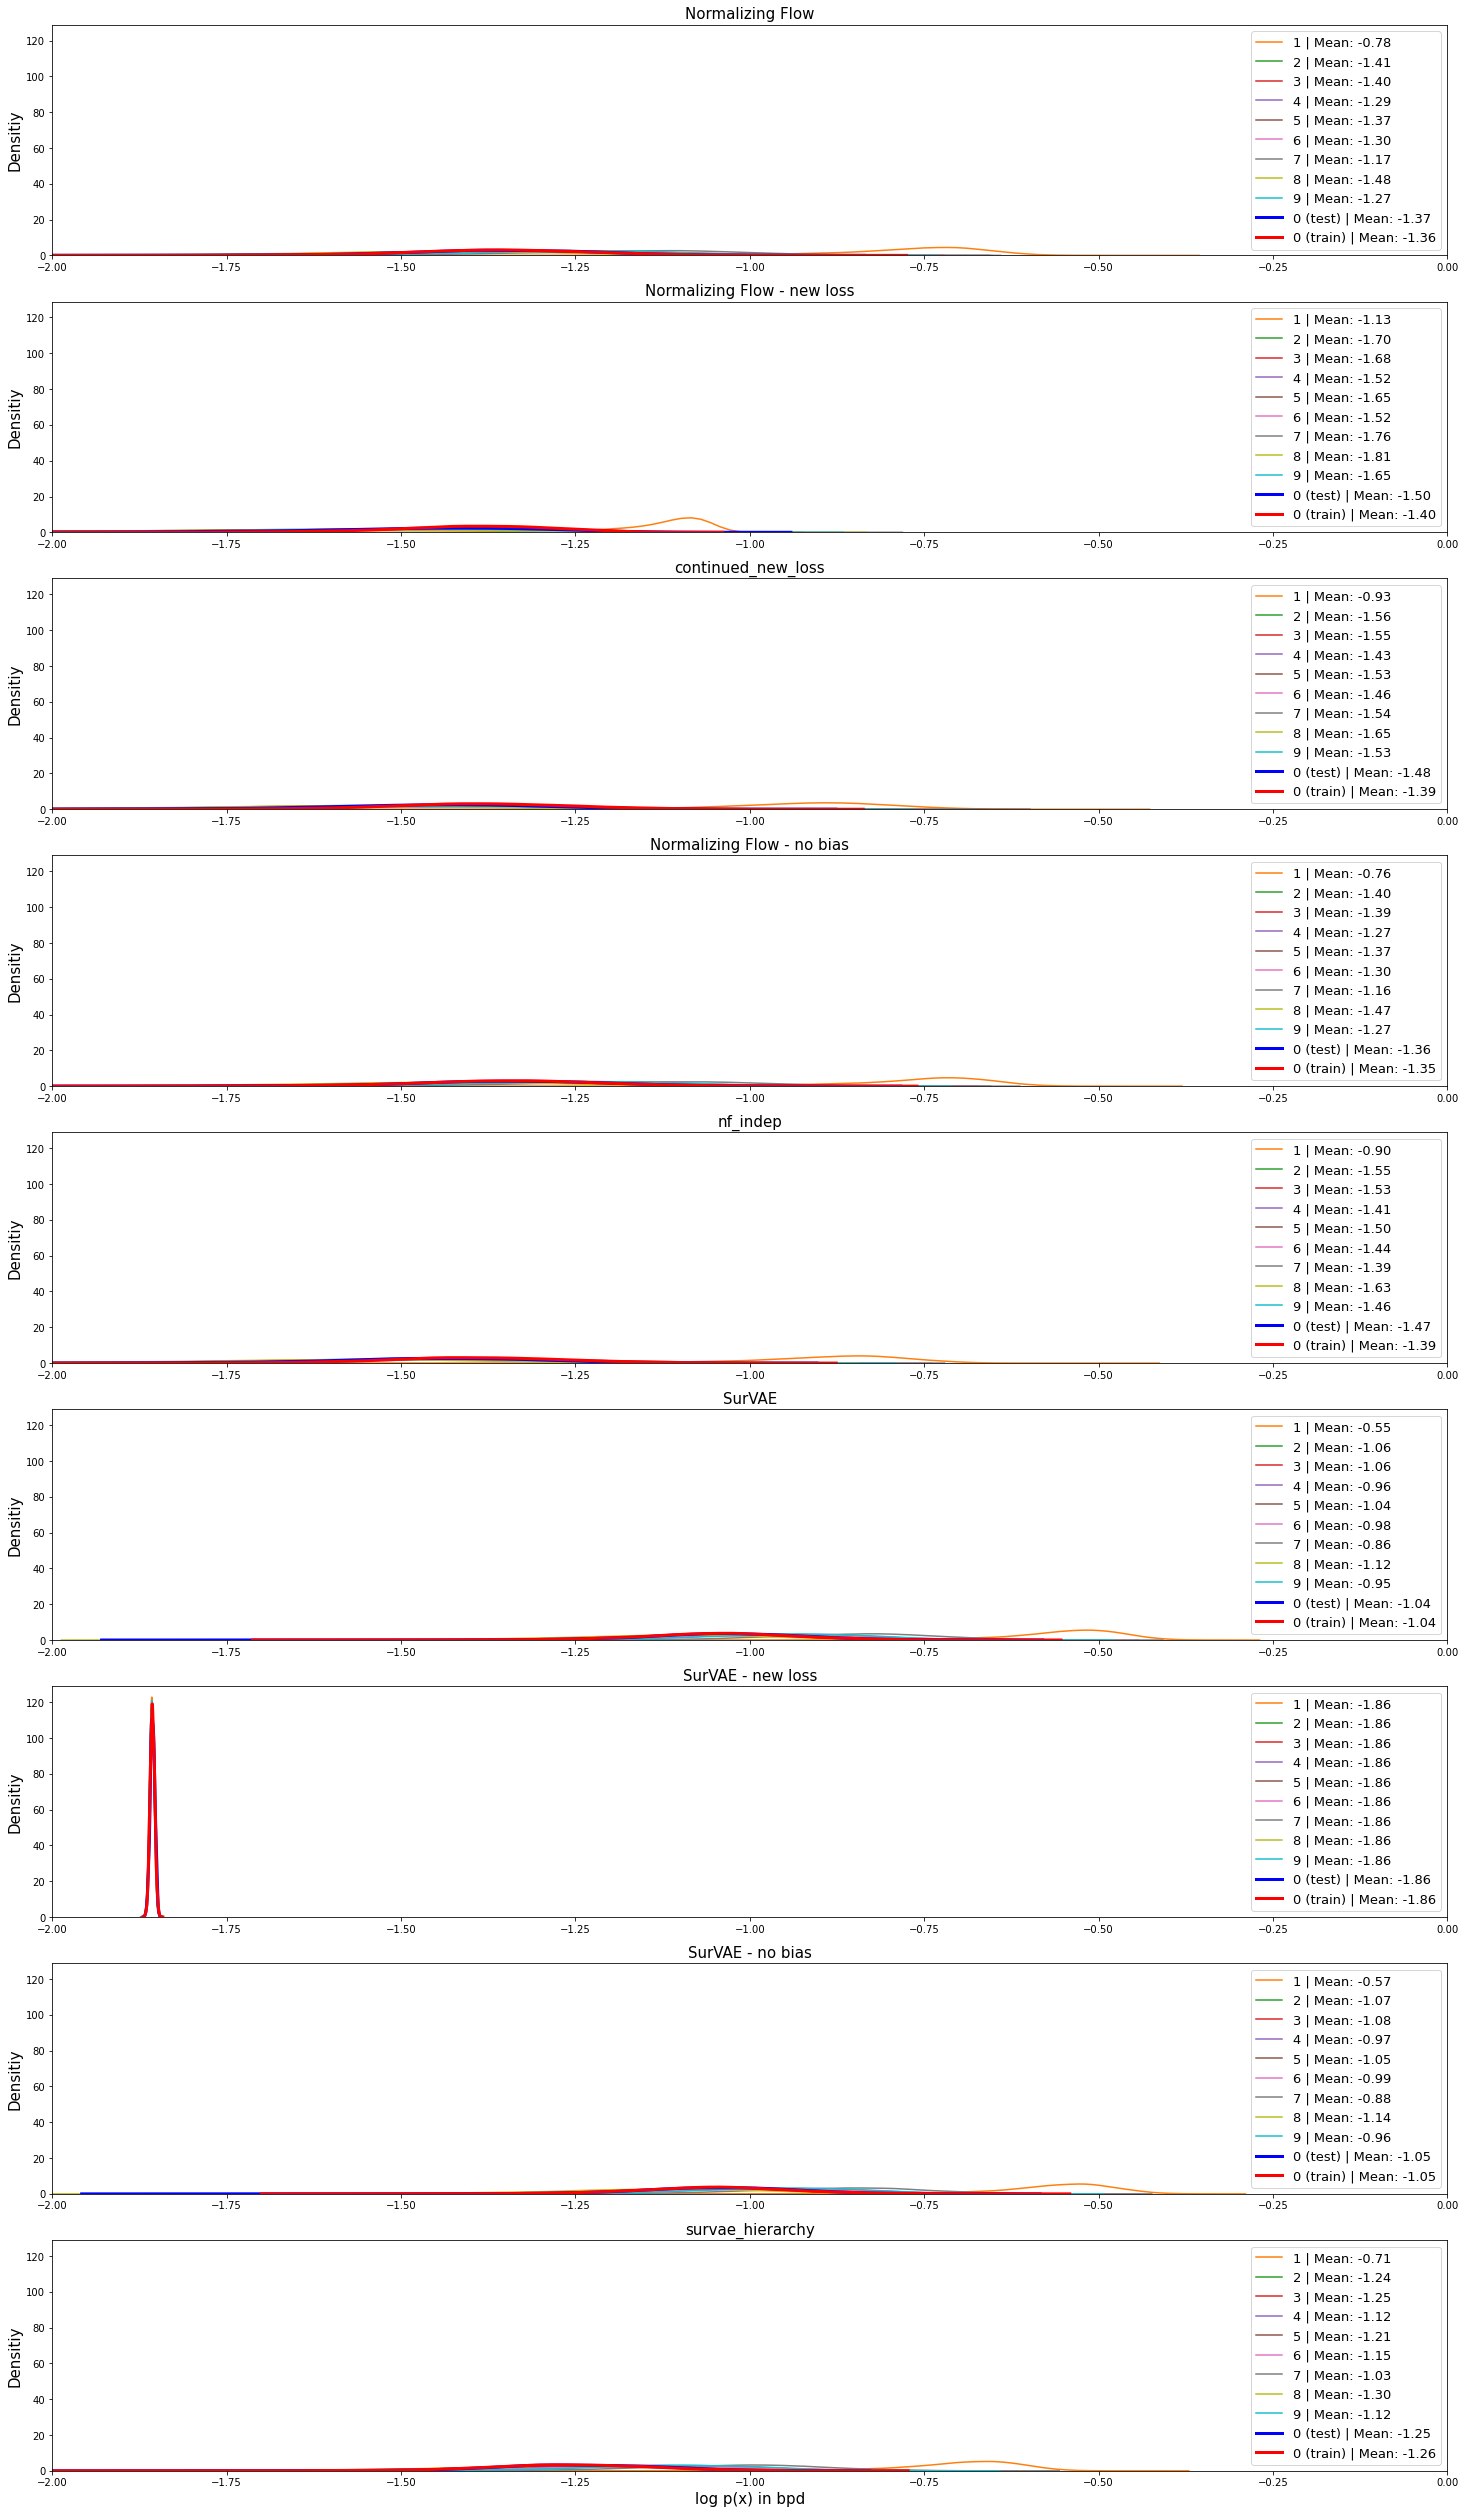

In [5]:
_=show_loss_histograms(no_iwae_losses, lim_left=-2.0, lim_right=0)

In [ ]:
_=show_loss_histograms(iwae_losses, lim_left=-20.0, lim_right=-10)#, lim_left=-2.0, lim_right=0)

#### This shows the means of $\{\pxbpd | x \in D_j\}$ for the given classes
Note that the x axis is aligned.

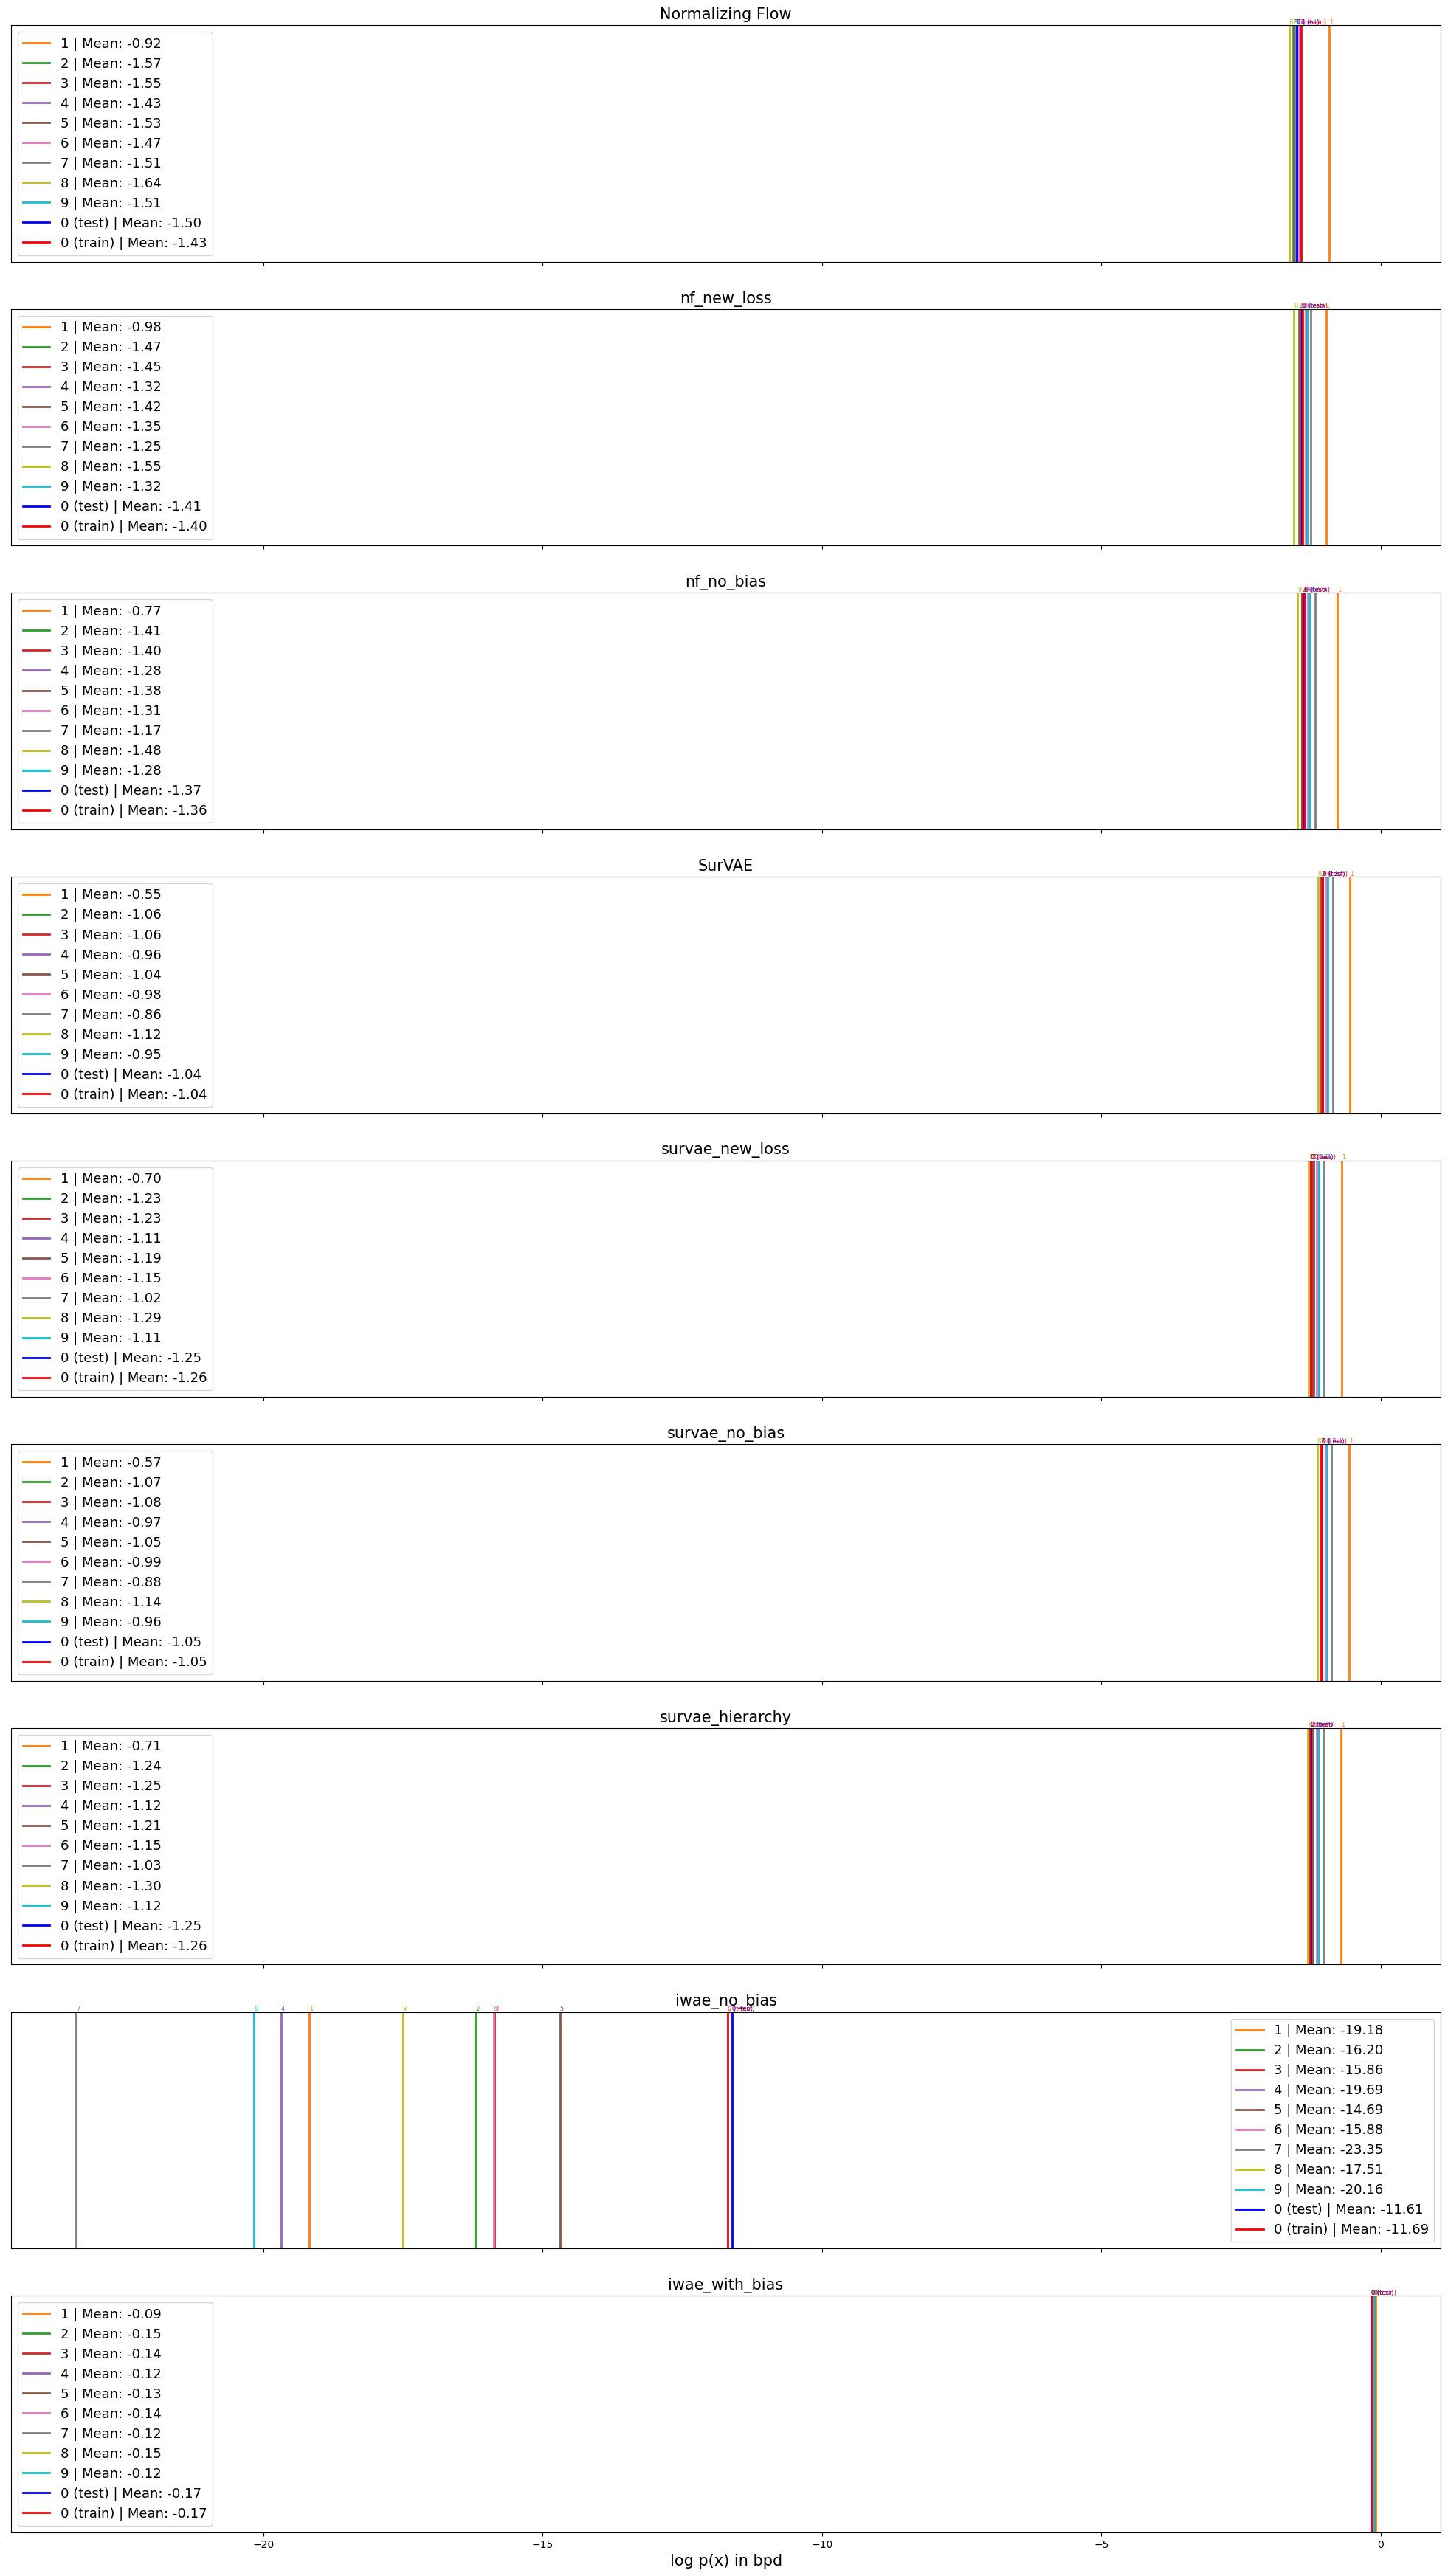

In [12]:
_=print_class_averages(all_losses)

------------------------------

--- 

# 4. Outlier Datapoints

In this section we look at real world samples from $D$ and plot the ones which obtain low and high likelihoods.<br>

The following images are plotted in the described order:<br>
$\lline$<br>
def outliers($\mathcal{S}$, highest, samples_per_class):<br>
$\quad$    T = []<br>
$\quad$    for $S \in \mathcal{S}$:<br>
$\qquad$        $P$ = sort($p_x(S)$)<br>
$\qquad$        if highest:<br>
$\qquad\quad$            revert order of $P_j$  # highest likelihood is in front<br>
$\qquad$        T += $P$[:samples_per_class]  # append the first samples_per_class likelihoods to T<br>
$\quad$    T' = sort(T)<br>
<br>
$\quad$    for t in T':<br>
$\qquad$      x = corresponding image of t<br>
$\qquad$      print(($\pxbpd$, the mean of all pixels, the class label))<br>
$\qquad$      plot x<br>
$\lline$<br>
Parameter explanation:<br>
$\mathcal{S}$ is a set of sets (partitions of $D$)<br>
highest: if True, we look at images with highest likelihood, if False: images with lowest likelihood<br>
samples_per_class: the amount of images per element of $\mathcal{S}$ we look at.<br>
$\lline$<br>


In an ad hoc way we controlled for the findings of [3] which is: more white pixel correlate with lower likelihood.<br>
White pixels are computed as the mean of all pixels for one image.<br>
By eyeballing we find similar results, although this correlation seems rather weak. <br>
Above each image we print ($\pxbpd$, the mean of all pixels, the class label).<br> 

[3] Ren, Jie, et al. "Likelihood ratios for out-of-distribution detection." arXiv preprint arXiv:1906.02845 (2019).

### 4.1.1 Images of main class $c$ with highest likelihood (descending)

We start with the overall best images of the main class in an ascending order. <br>
outliers($\{D_c^t, D_c^e\}$, True, 12) 

Title = (log p(x) in bpd, pixel mean, class)


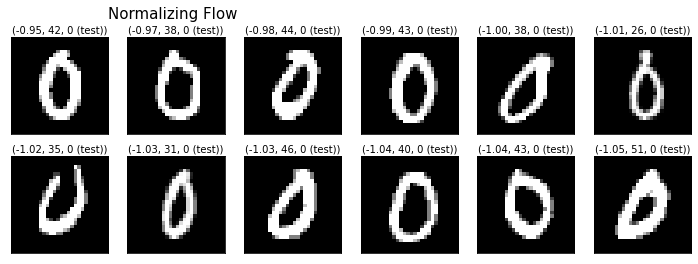

In [18]:
cols = 6
amount_per_class = 12
plot_best_or_worst_samples('nf', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=True, 
                           amount_per_class=amount_per_class, cols=cols)

Title = (log p(x) in bpd, pixel mean, class)


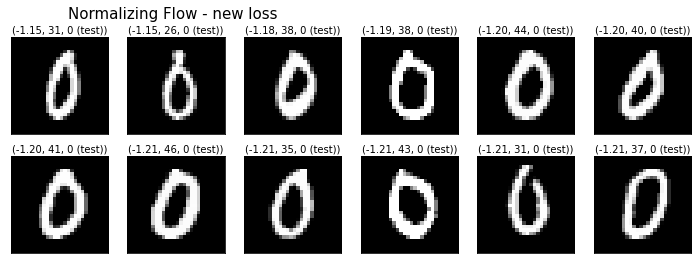

In [21]:
plot_best_or_worst_samples('nf_new_loss', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=True, 
                           amount_per_class=amount_per_class, cols=cols)

Title = (log p(x) in bpd, pixel mean, class)


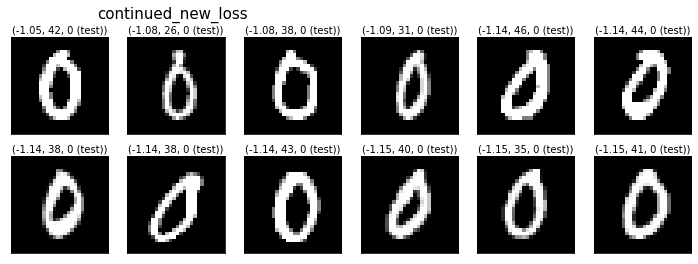

In [23]:
plot_best_or_worst_samples('continued_new_loss', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=True, 
                           amount_per_class=amount_per_class, cols=cols)

Title = (log p(x) in bpd, pixel mean, class)


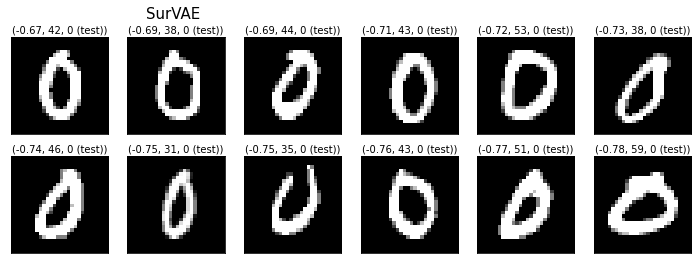

In [19]:
plot_best_or_worst_samples('survae', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=True, 
                           amount_per_class=amount_per_class, cols=cols)

Title = (log p(x) in bpd, pixel mean, class)


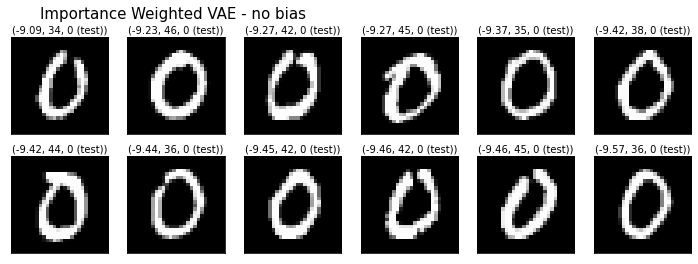

In [20]:
plot_best_or_worst_samples('iwae_no_bias', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=True, 
                           amount_per_class=amount_per_class, cols=cols)

Title = (log p(x) in bpd, pixel mean, class)


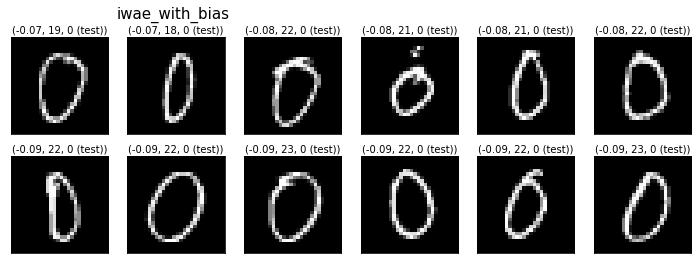

In [18]:
plot_best_or_worst_samples('iwae_with_bias', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=True, 
                           amount_per_class=amount_per_class, cols=cols)

### 4.1.2 Images of main class $c$ with lowest likelihood (ascending)
outliers($\{D_c^t, D_c^e\}$, False, 12) 

Title = (log p(x) in bpd, pixel mean, class)


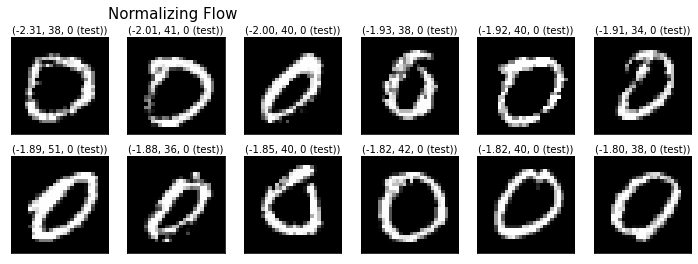

In [24]:
plot_best_or_worst_samples('nf', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, 
                           amount_per_class=amount_per_class, cols=cols, verbose=True)

Title = (log p(x) in bpd, pixel mean, class)


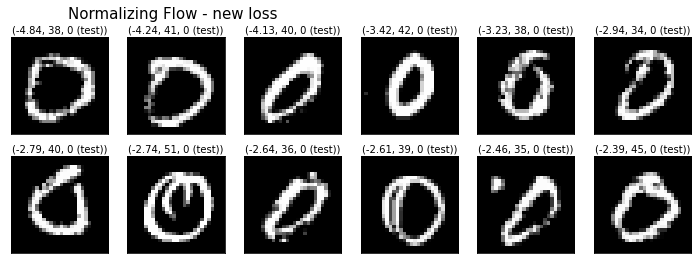

In [25]:
plot_best_or_worst_samples('nf_new_loss', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, 
                           amount_per_class=amount_per_class, cols=cols, verbose=True)

Title = (log p(x) in bpd, pixel mean, class)


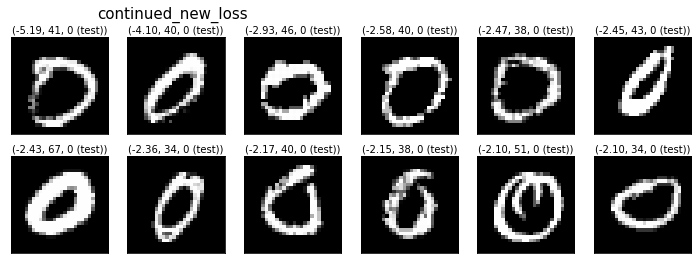

In [29]:
plot_best_or_worst_samples('continued_new_loss', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, 
                           amount_per_class=amount_per_class, cols=cols, verbose=True)

Title = (log p(x) in bpd, pixel mean, class)


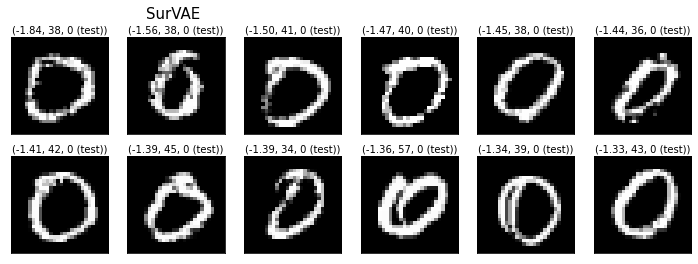

In [26]:
plot_best_or_worst_samples('survae', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, 
                           amount_per_class=amount_per_class, cols=cols, verbose=True)

Title = (log p(x) in bpd, pixel mean, class)


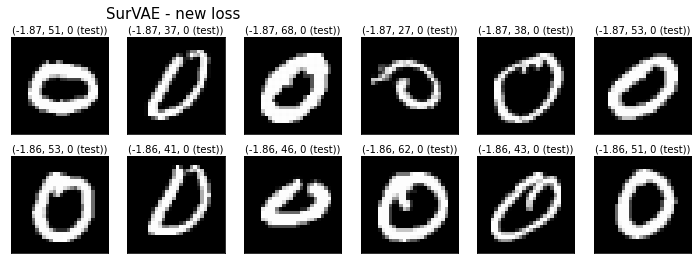

In [27]:
plot_best_or_worst_samples('survae_new_loss', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, 
                           amount_per_class=amount_per_class, cols=cols, verbose=True)

In [ ]:
plot_best_or_worst_samples('iwae', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, 
                           amount_per_class=amount_per_class, cols=cols, verbose=True)

In [ ]:
plot_best_or_worst_samples('iwae_with_bias', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, 
                           amount_per_class=amount_per_class, cols=cols, verbose=True)

### 4.2 Low / high likelihood samples of other classes
We want to see which images of other classes got high and low likelihoods.<br>
We replot the mean $\pxbpd$ of all classes to evaluate which are particularly interesting. 
For now we do this by hand.

In [ ]:
_=print_class_averages(iwae_losses)

$\textbf{The classes of interest are listed below.}$<br>

In [ ]:
cols = amount_per_class = 6
interesting_classes = [MAIN_TEST_CLS, MAIN_TRAIN_CLS, 1, 7, 8, 3]
interesting_losses = filter_interesting_losses(all_losses, interesting_classes)
no_iwae_interesting_losses = filter_interesting_losses(no_iwae_losses, interesting_classes)
iwae_interesting_losses = filter_interesting_losses(iwae_losses, interesting_classes)
best_imgs, worst_imgs = find_best_and_worst_images(interesting_classes, all_losses, all_loaders, amount_per_class)

This is some functionality to find the highest and lowest samples and to show them.

### 4.2.1 Images with high probability of interesting classes (descending)
outliers(interesting_classes, True, cols) 

In [ ]:
show_outliers(best_imgs['nf'], cols, 'nf', desc=True)

In [ ]:
show_outliers(best_imgs['survae'], cols, 'survae', desc=True)

In [ ]:
show_outliers(best_imgs['iwae'], cols, 'iwae', desc=True)

We replot the KDE plot of Section 3 and draw lines where the likelihood of the listed images are.

In [ ]:
plot_histogram_and_likelihoods(no_iwae_interesting_losses, best_imgs, lim_left=-3, lim_right=0)

In [ ]:
plot_histogram_and_likelihoods(iwae_interesting_losses, best_imgs, lim_left=-35, lim_right=-5)

### 4.2.2 Images with low probability of interesting classes (ascending)
outliers(interesting_classes, False, cols) 

In [ ]:
show_outliers(worst_imgs['nf'], cols, 'nf')

In [ ]:
show_outliers(worst_imgs['survae'], cols, 'survae')

In [ ]:
show_outliers(worst_imgs['iwae'], cols, 'iwae')

We replot the KDE plot of Section 3 and draw lines where the likelihood of the listed images are.

In [ ]:
plot_histogram_and_likelihoods(no_iwae_interesting_losses, worst_imgs)

In [ ]:
plot_histogram_and_likelihoods(iwae_interesting_losses, worst_imgs, lim_left=-35, lim_right=-5)

--- 
# 5 Likelihood of generated Images


In this section we generate images in the space of $\X$ (like an image with uniform noise) and what the likelihood of this image is.<br>
Note that this is just guessing.<br>

Notation:<br>
$j$: the mean of the log likelihoods of class $j$<br>
best sample: image with highest likelihood from plot 4.2.1 (probability a "1" for MNIST) <br>
worst sample: image with lowest likelihood from plot 4.2.2 <br>
black: a fully black image (i.e. all 0s) <br>
white: a fully white image (i.e. all 1d) <br>
0.5 * white: a image where all values are 0.5 <br>
Uni Noise: an image fully sampled from uniform noise in the range of $[0, 1]$ <br>
Uni Noise * 0.1: same as above but with a factor of 0.1 to the entire image (i.e. the image is really dark) <br>
black + $\epsilon$: an image where all values are small $\epsilon$
<br>

#### Some bad examples
Note that we will show the good ones and class averages for reference. <br>
We split this so good examples can be examined better.<br>
For Normalizing Flows:<br>
Note that just uniform noise is like -250 (thus we won't show it). <br>
For SurVAE: <br>
Interestingly, 0.1 * uniform noise gets really high likelihood as opposed to the Normalizing Flow.<br>
Even just uniform noise is still better than white.

In [ ]:
plot_lln_of_artificial_images(artificial_images, 'bad', interesting_losses, best_imgs, worst_imgs)

#### Some good examples
Note that x axis is shared here.

In [ ]:
plot_lln_of_artificial_images(artificial_images, 'good', interesting_losses, best_imgs, sharex=False)

# 5. Sampling

We now look at some samples to get an intuition of what the models have learned.<br>
The general sampling case works as follows:<br>
First we sample $z$ from the prior $G$.<br>
Then we apply our trained model $f(z)$ which will give us an image $x$.<br>
As we are interested in the probability distribution of $F$, we display $\pxibpd$.<br>
This seems counter intuitive at first, because we could also display the likelihood $z$ by using the known pdf $p_z(z)$.<br>
However, as $Z \sim G$, $f(Z) = X \sim F$. 
Thus, the likelihood of the displayed image $x$ is computed by $p_x$.

### 5.1 Random Samples
We start by looking at random samples drawn like:<br>
Sample $z$ and show $f(z)$.<br>
We see how our models seemed to have learned the main training class.

In [ ]:
plot_random_samples(samples, 'nf', cols=12)

In [ ]:
plot_random_samples(samples, 'survae', cols=12)

In [ ]:
plot_random_samples(samples, 'iwae', cols=12)

#### 5.2 Samples with likelihood
We now look at the $\pxbpd$ for random samples.<br>
The $\pxbpd$ is displayed above each image.<br>
The reason for the printed line is explained below.

In [ ]:
cols = 12
show_images_with_lln(samples, 'nf', SampleType.RANDOM_LIKELIHOOD, cols=cols, print_line=15)

We can see, that the $\pxbpd$ is really small compared to real world samples. <br>
We printed a line of the first image to show how $\fNF (z_i)$ seems to have problems in creating black pixel (i.e. of value 0).<br>
$\fSVAE$ does not seem to have this problem (see same line below).

In [ ]:
show_images_with_lln(samples, 'survae', SampleType.RANDOM_LIKELIHOOD, cols=cols, print_line=15)

In [ ]:
show_images_with_lln(samples, 'iwae', SampleType.RANDOM_LIKELIHOOD, cols=cols, print_line=15)

##### Cleaning of Samples likelihood

To overcome the problem mentioned above, we clean the images above. <br>
We used the same images as above, but applied cleaning function $h_{16}$. <br>
$h_{\beta}(x) = \frac{\lfloor x * \beta \rfloor}{\beta}$ <br>
It is noteworthy that the likelihood doesn't change much for $\beta$ equal to 8 or 16. 
For higher and lower values the likelihood becomes smaller.<br>
The displayed images are the 'cleaned' ones.<br>

Note that for there is an effect for SurVAE. 
But it goes into both direction (i.e. the likelihood gets better and worse).

In [ ]:
show_images_with_lln(samples, 'nf', SampleType.DIGITIZED_LIKELIHOOD, cols=cols)

In [ ]:
show_images_with_lln(samples, 'survae', SampleType.DIGITIZED_LIKELIHOOD, cols=cols)

In [ ]:
show_images_with_lln(samples, 'iwae', SampleType.DIGITIZED_LIKELIHOOD, cols=cols)

### 5.3 Special Samples
Let us look at some special samples.<br>
We start by looking at latent code $z$ with the same value in every dimension.<br>
That is $z_a = (a, a, ...,a)$.<br>
We clean the image as described above. That is $x_a = h_{16}(f(z_a))$.
The number above each image is $(a, p_x (x_a) \text{ in bpd})$ <br>

For Normalizing Flow:
It is noteworthy that the image $x_0$ obtains low likelihood despite $p_z(\tilde{z}_0)$ having the highest likelihood.<br>
I suppose this means that the likelihood contribution $V(x_0, \tilde{z}_0)$ is smaller than 1.

It would be interesting to see how an image with a really high likelihood looks like.<br>
But this is out of scope.
(This could be done by making a gradient descent on the input image).

In [ ]:
plot_unit_circle_image(samples, 'nf', SampleType.UNIT_CIRCLE_LIKELIHOOD, cols=cols)

In [ ]:
plot_unit_circle_image(samples, 'survae', SampleType.UNIT_CIRCLE_LIKELIHOOD, cols=cols)

In [ ]:
plot_unit_circle_image(samples, 'iwae', SampleType.UNIT_CIRCLE_LIKELIHOOD, cols=cols)

##### In this plot, we take random samples and put a factor to them in latent space. Each row comes from the same random sample.
for each row $r$:<br>
$\quad$   sample $z_r$ from the prior<br>
$\quad$   for $\alpha$ in factors:<br>
$\qquad$      plot $f(\alpha * z_r)$ in row $r$

the number above each column is the factor $\alpha$.

In [ ]:
plot_random_samples_with_factor(samples, 'nf', SampleType.RANDOM_FACTOR, row_count=3)

In [ ]:
plot_random_samples_with_factor(samples, 'survae', SampleType.RANDOM_FACTOR, row_count=3)

In [ ]:
plot_random_samples_with_factor(samples, 'iwae', SampleType.RANDOM_FACTOR, row_count=3)